# Lab 8.4.3 - Add Interactivity: User Input and Callbacks

## Exercise 1 - Average Monthly Arrival Delay Time
### Theme
Extract the average monthly arrival delay time and see how it changes over the year. The year range is from 2010 to 2020.

### Expected Output
The dashboard should consist of the following:
- Title - same as in the previous lab
- Input component - A field that allows user input of year
- Graph of the month vs average arrival delay time.

![Sample-dashboard](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/lab2_output.png)

### Tasks
1. Import libraries and read the dataset
2. Creating app layout and adding the title
3. Add input text box, callback decorator, and generate the line chart inside the callback function

---

### Task 1 - Import libraries and read the dataset

Along with the libraries imported in the previous lab, to be able to add interactivity, we have to import the `callback` module, as well as the `Output` and `Input` modules that are commonly used in the callback function.

In [1]:
# Import libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, html, dcc, callback, Output, Input

# Read the dataset
path = '/'.join(['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud',
                 'IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/airline_data.csv'])
airline_data = pd.read_csv(path)
airline_data.set_index('Year', inplace=True) #set index to Year

/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Below is a sample graph. The dashboard app should allow the chart to be changed based on user input for `Year`. We are going to use this code as template in building interactivity.

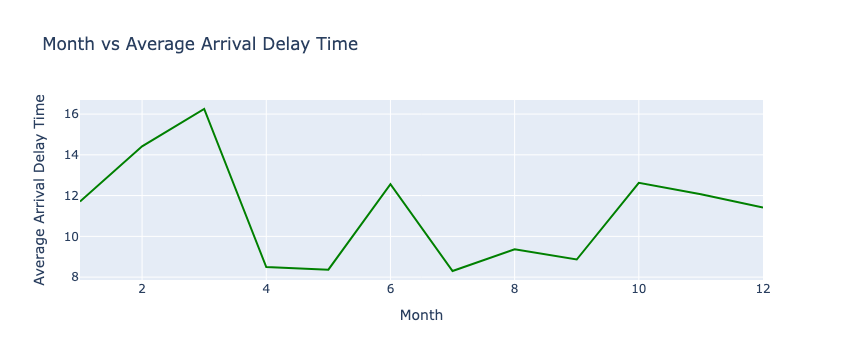

In [2]:
# Sample line graph
grouped = airline_data.loc[2010,['Month','ArrDelayMinutes']].groupby('Month').mean().reset_index()
px.line(grouped, x='Month', y='ArrDelayMinutes',
        title='Month vs Average Arrival Delay Time',
        labels={'ArrDelayMinutes':'Average Arrival Delay Time'},
        color_discrete_sequence=['green'])

### Task 2 - Creating app layout and adding the title

In [ ]:
# Initialize the app
app = Dash()

The expected output must consist of:
- The title -- for this, we will use `html.H1()` component.
- The input box -- We can use the dashboard core component `dcc.input()` for this.
- The graph -- We can use `dcc.Graph()`; but, we expect the graph to be dynamic. So, we don't define the graph completely in building the layout.

From this, the layout skeleton should look like

In [ ]:
# App layout
app.layout = [html.H1(...),  # <-- Title
             html.Div(children=['Input Year: ',....]),  # <-- Input Box inside Div children
             dcc.Graph(....)]  # <-- Graph 

The title does not change with different user input. So, we can define it completely in the layout.

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',....]),  # <-- Input Box inside Div children
             dcc.Graph(....)]  # <-- Graph 

### Task 3 - Input text box, callback decorator, and line chart

The input box can be added using `dcc.Input()`. We provide a (sort of) initial value by assigning the year `2010` to the property `value`, and we give the component an `id`. This `id` will be used in the callback function -- a way to determine the component that involves input.

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',
                                dcc.Input(type='number',
                                          value=2010,
                                          id='controls-and-input')]),
             dcc.Graph(....)]  # <-- Graph 

Considering that the year range is from 2010 to 2020, we can set minimum and maximum values for the input.

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(['Input Year: ',
                        dcc.Input(type='number',
                                  value=2010,
                                  id='controls-and-input',
                                  min=2010,
                                  max=2020)]),
             dcc.Graph(....)]  # <-- Graph 

Since the graph depends on the input for year, i.e., the `value` property of the `Input` component, we will only give it an `id`, to be used in the callback function, and add an empty graph.

In [ ]:
# App layout
app.layout = [html.H1('Airline Dashboard',
                      style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',
                        dcc.Input(type='number',
                                  value=2010,
                                  id='controls-and-input',
                                  min=2010,
                                  max=2020)]),
             dcc.Graph(figure={}, id='controls-and-graph')]

Finally, we build the interaction using a `callback` function.
- In this case we pass the `id` and `figure` properties of the `dcc.Graph()` component to the `Output` function. This assigns the output of the callback to the `figure` property of the `dcc.Graph()` component.
- For the `Input` function, we pass the `id` and `value` of the `dcc.Input()` component. When a user changes the value in the input box, this function should take care of retrieving that input and assigning it to the `value` property.
- Finally, we define the function. The argument here, `year_chosen`, refers to the `value` property of the `dcc.Input()` component; the body is a copy of the sample graph we did above; and the function returns `fig` which will be assigned to the `figure` property.

In [ ]:
# Add controls to build the interaction
@callback(
    Output(component_id='controls-and-graph', component_property='figure'),
    Input(component_id='controls-and-input', component_property='value')
)
def update_graph(year_chosen):
    grouped = airline_data.loc[year_chosen,['Month','ArrDelayMinutes']].groupby('Month').mean().reset_index()
    fig = px.line(grouped, x='Month', y='ArrDelayMinutes',
                  title='Month vs Average Arrival Delay Time',
                  labels={'ArrDelayMinutes':'Average Arrival Delay Time'},
                  color_discrete_sequence=['green'])
    return fig

# Run the app
if __name__ == '__main__':
    app.run(jupyter_mode="external")

A snippet of the dashboard:

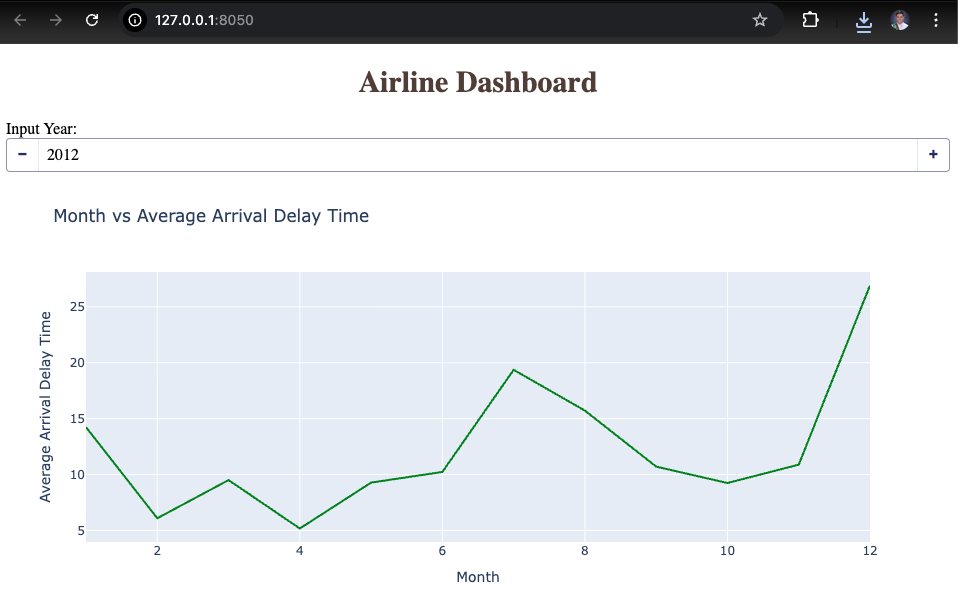

## Exercise 2 - Total number of flights to destination state

### Theme
Extract the number of flights that goes to a destination.

### Expected Output
The output should contain the following components:
- Title of the application
- Component to enter input year
- A chart conveying the total number of flights to the destination state.

![expected-output-2](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/Bar_chart_activity.png)

---

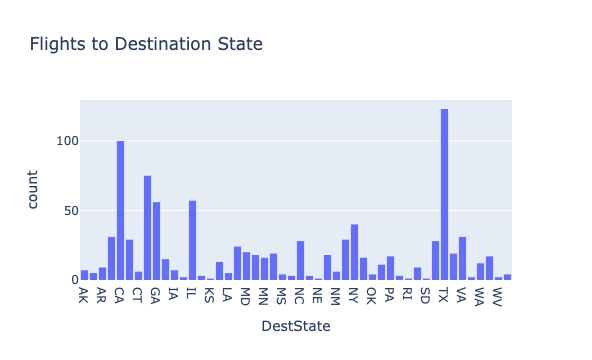

In [19]:
# Test Graph
px.histogram(airline_data.loc[2010,:].sort_values(by='DestState'),
             x='DestState', y='Flights', histfunc='count',
             title='Flights to Destination State')

In [23]:
app = Dash() # Initialize App

# App Layout
app.layout = [html.H1('Total number of flights to the destination state split by reporting airline',
                     style={'color': '#503D36',
                             'font-size': 30,
                             'textAlign': 'center'}),
             html.Div(children=['Input Year: ',
                                dcc.Input(type='number', value=2010, min=2010, max=2020,
                                          id='input-box-id')]),
             dcc.Graph(figure={}, id='graph-id')]

# Callback
@callback(
    Output(component_id='graph-id', component_property='figure'),
    Input(component_id='input-box-id', component_property='value')
)
def update_graph(chosen_year):
    fig = px.histogram(airline_data.loc[chosen_year,:].sort_values(by='DestState'),
                       x='DestState', y='Flights', histfunc='count',
                       title='Flights to Destination State')
    return fig

# Run the app
if __name__ == '__main__':
    app.run(jupyter_mode='external')

Dash app running on http://127.0.0.1:8050/


Snippet of the dashboard:

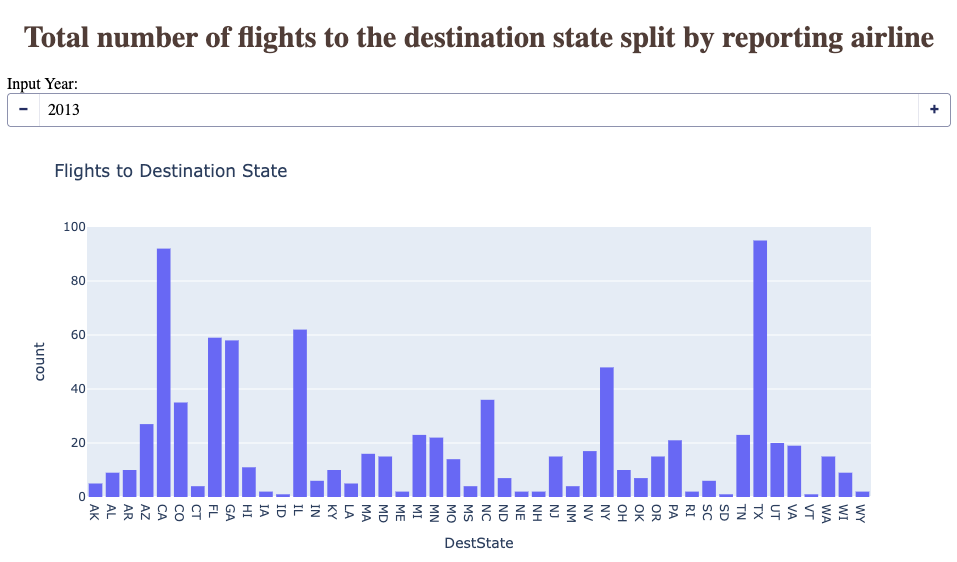